# Chapter 3 — Unsupervised Learning and Preprocessing

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the role of preprocessing in machine learning.
2. Apply scaling methods such as StandardScaler and MinMaxScaler.
3. Understand why scaling must be fitted on training data only.
4. Use PCA for dimensionality reduction and visualization.
5. Apply clustering methods such as KMeans and DBSCAN.
6. Interpret unsupervised learning results carefully.

## Chapter Overview

Unsupervised learning is used when there is no target label. The algorithm tries to discover structure in the input data. Common unsupervised tasks include dimensionality reduction, feature extraction, and clustering.

Preprocessing is also discussed in this chapter because many models are sensitive to feature scale. Even though preprocessing is often used before supervised learning, many preprocessing methods learn only from `X`, not from `y`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset Preparation

This notebook uses the Breast Cancer dataset for preprocessing and PCA examples. Even though the dataset has labels, PCA itself does not use the labels when learning the transformation.

In [2]:
from sklearn.datasets import load_breast_cancer, make_blobs

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print('Data shape:', X.shape)
print('Number of features:', len(cancer.feature_names))
print('Target names:', cancer.target_names)

Data shape: (569, 30)
Number of features: 30
Target names: ['malignant' 'benign']


### Output Interpretation

The dataset has many numerical features with different ranges. Scaling is important because algorithms based on distance or variance can be dominated by features with larger numerical values.

## 2. Feature Scaling with StandardScaler and MinMaxScaler

### Theory

- `StandardScaler` transforms each feature to have mean 0 and standard deviation 1.
- `MinMaxScaler` transforms each feature into a fixed range, usually 0 to 1.

Scaling should be fitted on the training set only. The learned transformation is then applied to both training and test sets.

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=RANDOM_STATE
)

standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

minmax_scaler = MinMaxScaler()
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

print('Original training mean of first 3 features:', np.round(X_train[:, :3].mean(axis=0), 2))
print('Standard scaled mean of first 3 features:', np.round(X_train_standard[:, :3].mean(axis=0), 2))
print('MinMax scaled min of first 3 features:', np.round(X_train_minmax[:, :3].min(axis=0), 2))
print('MinMax scaled max of first 3 features:', np.round(X_train_minmax[:, :3].max(axis=0), 2))

Original training mean of first 3 features: [14.08 19.3  91.59]
Standard scaled mean of first 3 features: [-0.  0. -0.]
MinMax scaled min of first 3 features: [0. 0. 0.]
MinMax scaled max of first 3 features: [1. 1. 1.]


### Output Interpretation

After standardization, feature means are close to zero. After MinMax scaling, training features are mapped between 0 and 1. The same transformation must be applied to test data to avoid inconsistent feature representation.

## 3. Effect of Scaling on SVM

SVM with an RBF kernel is sensitive to feature scale. This example compares SVM performance before and after scaling.

In [4]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_unscaled = SVC(C=10, gamma='scale')
svm_unscaled.fit(X_train, y_train)

svm_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=10, gamma='scale'))
])
svm_scaled.fit(X_train, y_train)

print('SVM test accuracy without scaling:', round(svm_unscaled.score(X_test, y_test), 4))
print('SVM test accuracy with scaling   :', round(svm_scaled.score(X_test, y_test), 4))

SVM test accuracy without scaling: 0.9231
SVM test accuracy with scaling   : 0.979


### Output Interpretation

If scaling improves performance, it means feature magnitudes were affecting the model. This is common for distance-based and kernel-based methods.

## 4. Principal Component Analysis (PCA)

PCA is an unsupervised dimensionality reduction method. It finds directions of maximum variance in the data and projects the data onto those directions.

### Important theory

PCA does not use class labels. If a PCA plot shows class separation, that means the main directions of variance also happen to be useful for distinguishing classes.

In [5]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print('Original shape:', X_scaled.shape)
print('Reduced shape:', X_pca.shape)
print('Explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))

Original shape: (569, 30)
Reduced shape: (569, 2)
Explained variance ratio: [0.4427 0.1897]


### Output Interpretation

The dataset is reduced from many features to two principal components. The explained variance ratio shows how much of the original variance is captured by each component.

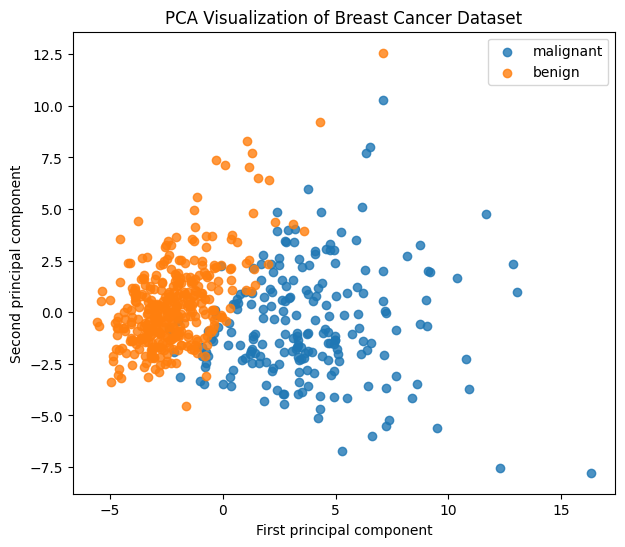

In [6]:
plt.figure(figsize=(7, 6))
for target_value, target_name in enumerate(cancer.target_names):
    plt.scatter(
        X_pca[y == target_value, 0],
        X_pca[y == target_value, 1],
        label=target_name,
        alpha=0.8
    )
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('PCA Visualization of Breast Cancer Dataset')
plt.legend()
plt.show()

### Output Interpretation

The PCA scatter plot helps visualize high-dimensional data in two dimensions. If the two classes appear separated, it suggests that the dataset contains strong structure that can be captured by a small number of components.

## 5. KMeans Clustering

KMeans groups data into a predefined number of clusters. It assigns each sample to the nearest cluster center.

### Theory

KMeans works well when clusters are roughly spherical and similar in size. It requires the number of clusters to be specified in advance.

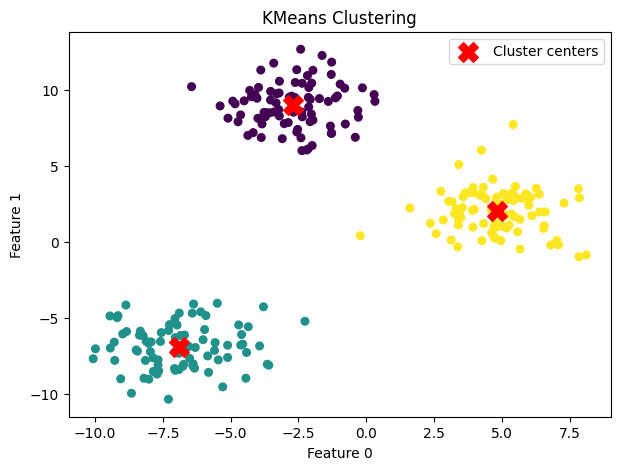

Cluster centers:
[[-2.7   9.01]
 [-6.89 -6.88]
 [ 4.82  2.04]]


In [7]:
from sklearn.cluster import KMeans

X_blobs, y_blobs = make_blobs(n_samples=250, centers=3, cluster_std=1.5, random_state=RANDOM_STATE)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_blobs)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap='viridis', s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Cluster centers')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.title('KMeans Clustering')
plt.legend()
plt.show()

print('Cluster centers:')
print(np.round(kmeans.cluster_centers_, 2))

### Output Interpretation

Each color represents a cluster assigned by KMeans. The red X markers are cluster centers. Since KMeans is unsupervised, the cluster labels are not the same as class labels; they are arbitrary group identifiers.

## 6. DBSCAN Clustering

DBSCAN is a density-based clustering algorithm. It can find clusters with irregular shapes and can mark some points as noise.

### Important parameters

- `eps`: neighborhood radius.
- `min_samples`: minimum number of nearby points needed to form a dense region.

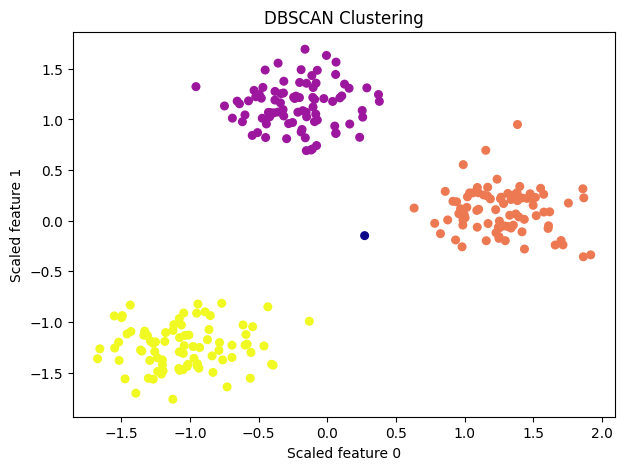

Unique cluster labels: [-1  0  1  2]
Number of noise points: 1


In [8]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X_blobs_scaled = StandardScaler().fit_transform(X_blobs)
dbscan = DBSCAN(eps=0.45, min_samples=5)
db_labels = dbscan.fit_predict(X_blobs_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=db_labels, cmap='plasma', s=30)
plt.xlabel('Scaled feature 0')
plt.ylabel('Scaled feature 1')
plt.title('DBSCAN Clustering')
plt.show()

print('Unique cluster labels:', np.unique(db_labels))
print('Number of noise points:', np.sum(db_labels == -1))

### Output Interpretation

DBSCAN labels noise points as `-1`. Unlike KMeans, DBSCAN does not require the number of clusters in advance. However, it is sensitive to `eps` and feature scaling.

## Key Takeaways

- Unsupervised learning finds structure without target labels.
- Scaling is essential for many algorithms, especially distance-based methods.
- Scaling must be fitted on training data only to avoid data leakage.
- PCA reduces dimensionality and helps visualize high-dimensional data.
- KMeans requires the number of clusters in advance.
- DBSCAN can detect noise and irregular cluster shapes.

## Chapter Summary

Chapter 3 explains how preprocessing and unsupervised learning support the machine learning workflow. Scaling improves model behavior, PCA helps reduce dimensionality, and clustering methods reveal possible structure in unlabeled data.